<a href="https://colab.research.google.com/github/darshbaxi/Emoji_prediction/blob/main/AE_Low_Light_Image_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
soumikrakshit_lol_dataset_path = kagglehub.dataset_download('soumikrakshit/lol-dataset')

print('Data source import complete.')


Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lol-dataset/lol_dataset/eval15/low/780.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/778.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/493.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/669.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/547.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/55.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/1.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/748.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/22.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/146.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/179.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/665.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/23.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/111.png
/kaggle/input/lol-dataset/lol_dataset/eval15/low/79.png
/kaggle/input/lol-dataset/lol_dataset/eval15/high/780.png
/kaggle/input/lol-dataset/lol_dataset/eval15/high/778.png
/kaggle/input/lol-dataset/lol_datas

# Import Libraries

In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import cv2
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import plot_model, img_to_array

from IPython import display

# Load Data

In [5]:
high_light_train_images_path = "/kaggle/input/lol-dataset/lol_dataset/our485/high"
low_light_train_images_path = "/kaggle/input/lol-dataset/lol_dataset/our485/low"

In [6]:
high_light_test_images_path = "/kaggle/input/lol-dataset/lol_dataset/eval15/high"
low_light_test_images_path = "/kaggle/input/lol-dataset/lol_dataset/eval15/low"

In [7]:
SIZE = 256

In [8]:
def load_images(path, size=224, count=None):
    if count == None:
        files = os.listdir(path)
    else:
        files = os.listdir(path)[:count]
    images = []

    for file in tqdm.tqdm(files):
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size))
        img = img.astype("float32") / 255.
        img = img_to_array(img)
        images.append(img)

    images = np.array(images)
    return images

In [9]:
train_low_images = load_images(low_light_train_images_path, size=SIZE)

100%|██████████| 485/485 [00:06<00:00, 71.13it/s]


In [10]:
train_high_images = load_images(high_light_train_images_path, size=SIZE)

100%|██████████| 485/485 [00:06<00:00, 71.72it/s]


In [11]:
test_low_images = load_images(low_light_test_images_path, size=SIZE)

100%|██████████| 15/15 [00:00<00:00, 67.55it/s]


In [12]:
test_high_images = load_images(high_light_test_images_path, size=SIZE)

100%|██████████| 15/15 [00:00<00:00, 58.13it/s]


# Visualization

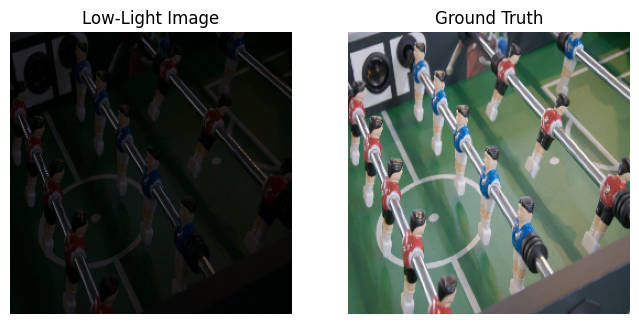

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))

axes[0].imshow(train_low_images[10])
axes[0].set_title("Low-Light Image")
axes[0].axis("off")

axes[1].imshow(train_high_images[10])
axes[1].set_title("Ground Truth")
axes[1].axis("off")

plt.show()

# Model

In [14]:
def down_block(x, filters, kernel_size, apply_batch_normalization=True):
    x = layers.Conv2D(filters, kernel_size, padding="same", strides=2)(x)
    if apply_batch_normalization:
        x = layers.BatchNormalization()(x)

    x = layers.LeakyReLU()(x)
    return x

In [15]:
def up_block(x, skip, filters, kernel_size, dropout=False):
    x = layers.Conv2DTranspose(filters, kernel_size, padding="same", strides=2)(x)
    if dropout:
        x = layers.Dropout(0.1)(x)

    x = layers.LeakyReLU()(x)
    x = layers.concatenate([x, skip])
    return x

In [16]:
def build_model(size):
    inputs = layers.Input(shape=[size, size, 3])

    # Downsampling
    d1 = down_block(inputs, 128, (3, 3), apply_batch_normalization=False)
    d2 = down_block(d1, 128, (3, 3), apply_batch_normalization=False)
    d3 = down_block(d2, 256, (3, 3), apply_batch_normalization=True)
    d4 = down_block(d3, 512, (3, 3), apply_batch_normalization=True)
    d5 = down_block(d4, 512, (3, 3), apply_batch_normalization=True)

    # Upsampling
    u1 = up_block(d5, d4, 512, (3, 3), dropout=False)
    u2 = up_block(u1, d3, 256, (3, 3), dropout=False)
    u3 = up_block(u2, d2, 128, (3, 3), dropout=False)
    u4 = up_block(u3, d1, 128, (3, 3), dropout=False)

    # Final upsampling
    u5 = layers.Conv2DTranspose(64, (3, 3), padding='same', strides=2)(u4)
    u5 = layers.LeakyReLU()(u5)
    u5 = layers.concatenate([u5, inputs])

    # Output layer
    outputs = layers.Conv2D(3, (1, 1), activation='sigmoid', padding='same')(u5)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

In [17]:
model = build_model(size=SIZE)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      3,584 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │    147,584 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    295,168 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ leaky_re_lu_2[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,359,808 │ leaky_re_lu_4[0]… │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ leaky_re_lu_5[0]… │
│ (Concatenate)       │ 1024)             │            │ leaky_re_lu_3[0]

 Total params: 9,743,500 (37.17 MB)

 Trainable params: 9,740,940 (37.16 MB)

 Non-trainable params: 2,560 (10.00 KB)

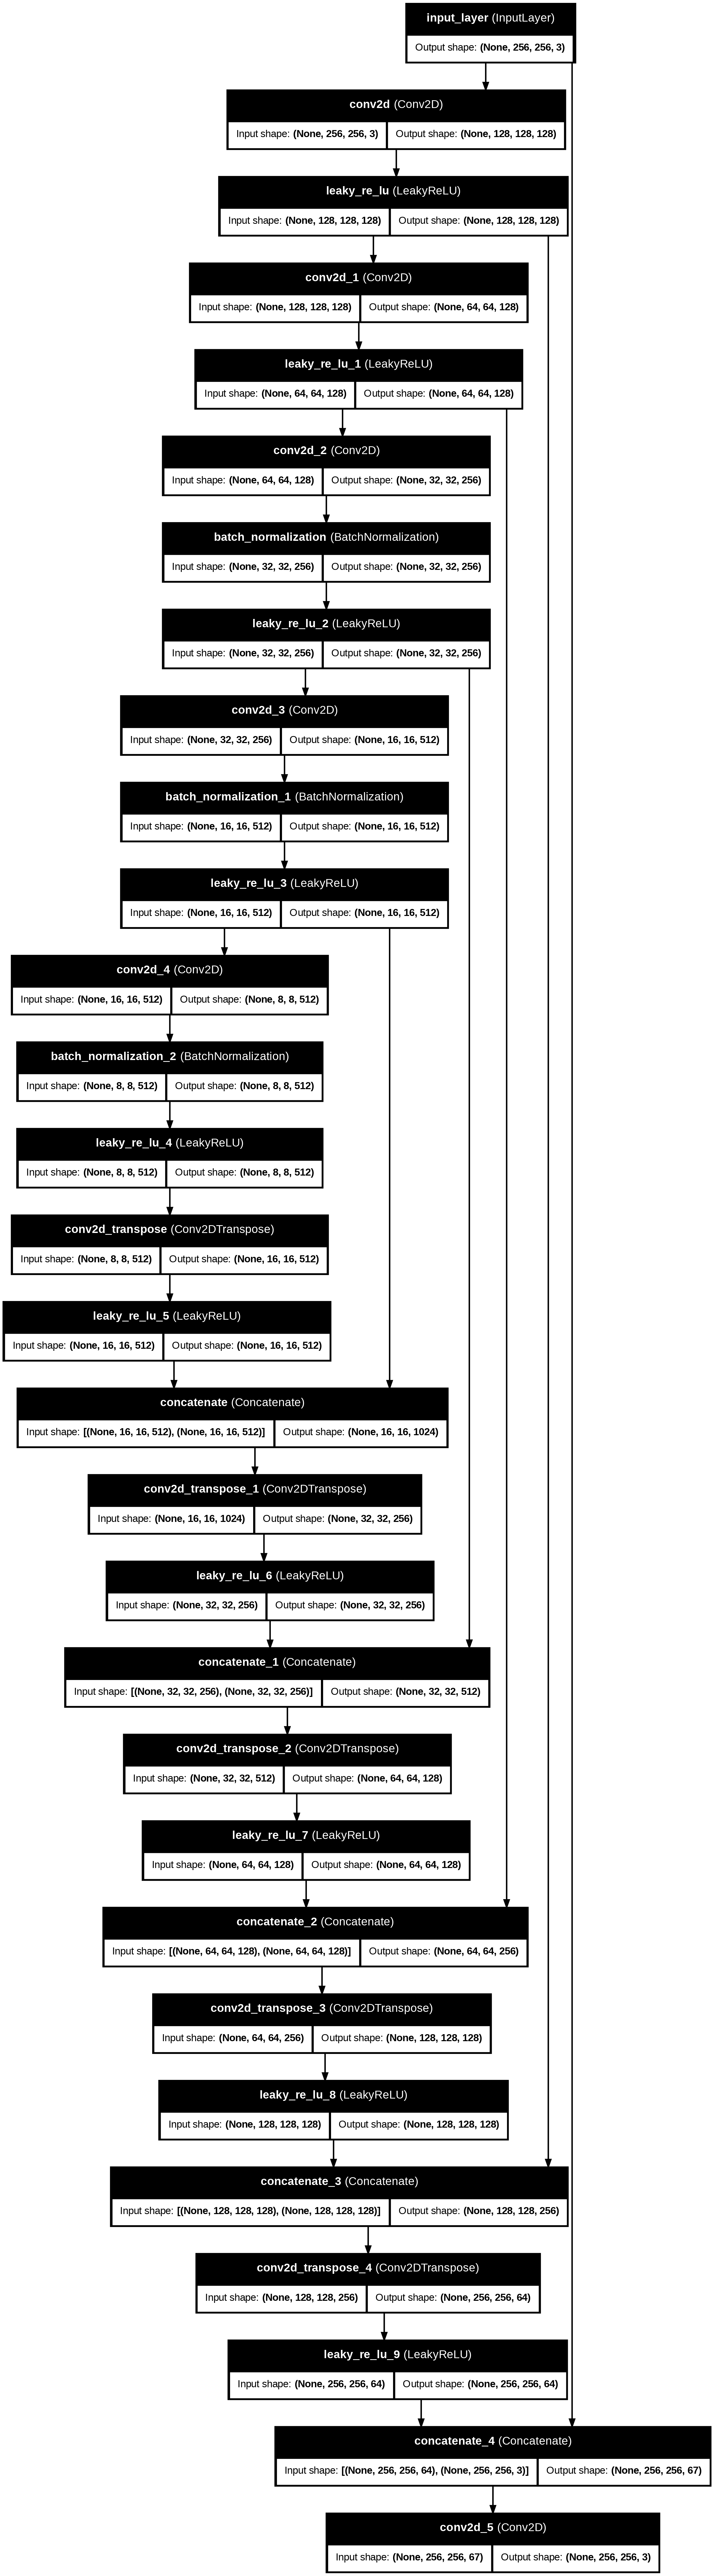

In [19]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [20]:
model.compile(
    optimizer = optimizers.Adam(learning_rate=0.001),
    loss = "mean_absolute_error",
    metrics = ["accuracy"]
)

# Train

In [21]:
history = model.fit(
    train_low_images,
    train_high_images,
    epochs = 15,
    batch_size = 16,
    validation_data=(test_low_images, test_high_images),
    verbose = 1
)

Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 44s 738ms/step - accuracy: 0.4607 - loss: 0.1585 - val_accuracy: 0.5510 - val_loss: 0.1782
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.5359 - loss: 0.1283 - val_accuracy: 0.6109 - val_loss: 0.1685
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.5984 - loss: 0.1255 - val_accuracy: 0.6996 - val_loss: 0.1653
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.6354 - loss: 0.1168 - val_accuracy: 0.6491 - val_loss: 0.1514
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - accuracy: 0.6543 - loss: 0.1177 - val_accuracy: 0.7159 - val_loss: 0.1372
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.6853 - loss: 0.1163 - val_accuracy: 0.7441 - val_loss: 0.1452
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 0.6883 - loss: 0.1135 - val_accuracy: 0.7520 - val_loss: 0.1334
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 236ms/step - accuracy: 0.6915 - loss: 0.1156 - val_accuracy

In [22]:
model.save("image_enhancement.h5")

In [28]:
model.load_weights('image_enhancement.h5')

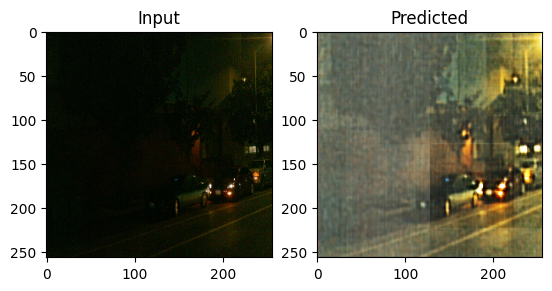

In [31]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# ---- 1. Load the model ----
model = load_model('image_enhancement.h5')

# ---- 2. Load and preprocess the image ----
image_path = 'val00-16-2-2-FRONT_LEFT.jpg'   # replace with your image path
size = 256                # replace with your model's input size (e.g., 128)

# Load image and resize
img = load_img(image_path, target_size=(size, size))
img_array = img_to_array(img) / 255.0   # Normalize to [0,1]
input_image = np.expand_dims(img_array, axis=0)  # Shape: (1, size, size, 3)

# ---- 3. Predict ----
predicted = model.predict(input_image, verbose=0)
predicted = np.clip(predicted, 0.0, 1.0).reshape(size, size, 3)

# ---- 4. Display result ----
plt.subplot(1, 2, 1)
plt.title("Input")
plt.imshow(img_array)

plt.subplot(1, 2, 2)
plt.title("Predicted")
plt.imshow(predicted)
plt.show()


# Results

In [23]:
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.496479,0.146308,0.550979,0.178205
1,0.551902,0.129045,0.610887,0.168450
2,0.624480,0.123949,0.699611,0.165282
3,0.638971,0.121113,0.649135,0.151448
4,0.679144,0.117375,0.715937,0.137203


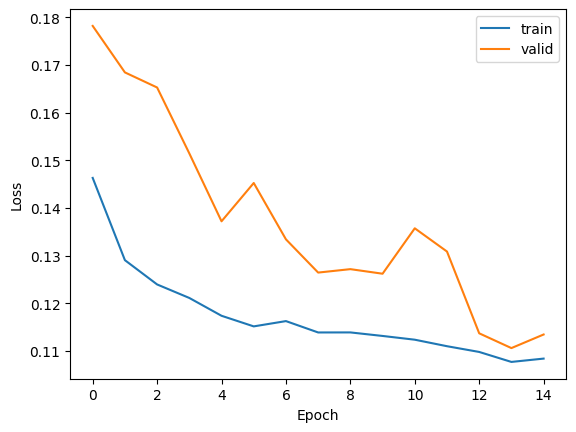

In [24]:
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train", "valid"])
plt.show()

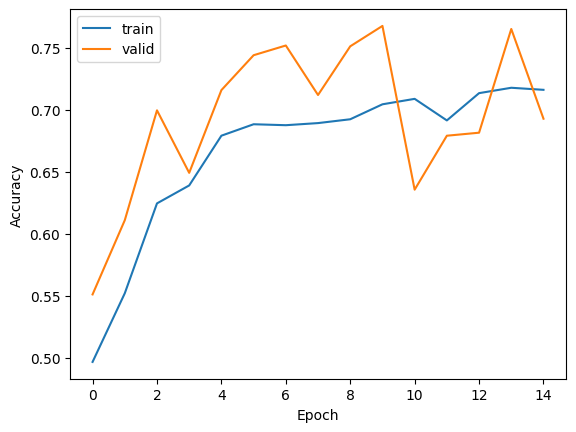

In [25]:
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "valid"])
plt.show()

In [26]:
def predict_images(test_low, test_high, count=5, size=224):
    for _ in range(count):
        random_idx = np.random.randint(len(test_low))
        predicted = model.predict(test_low[random_idx].reshape(1, size, size, 3), verbose=0)
        predicted = np.clip(predicted, 0.0, 1.0).reshape(size, size, 3)

        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

        axes[0].imshow(test_low[random_idx])
        axes[0].set_title("Low-Light Image")
        axes[0].axis("off")

        axes[1].imshow(test_high[random_idx])
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        axes[2].imshow(predicted)
        axes[2].set_title("Enhanced Image")
        axes[2].axis("off")

        plt.show()

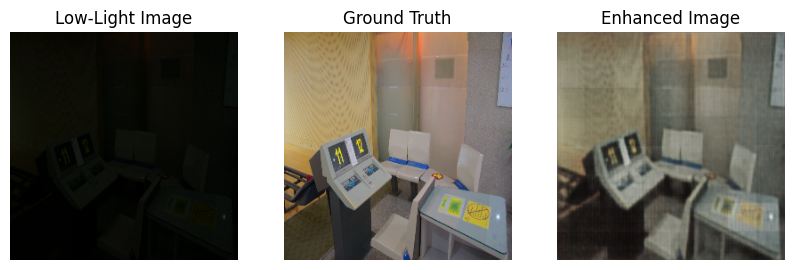

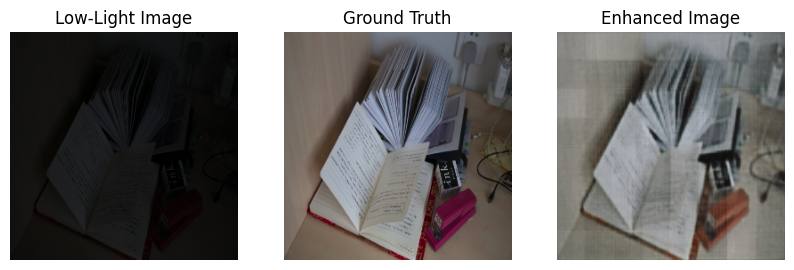

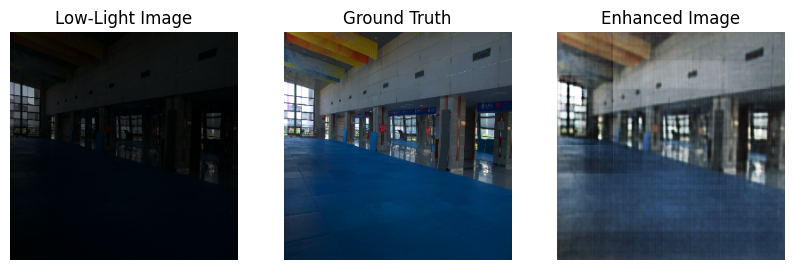

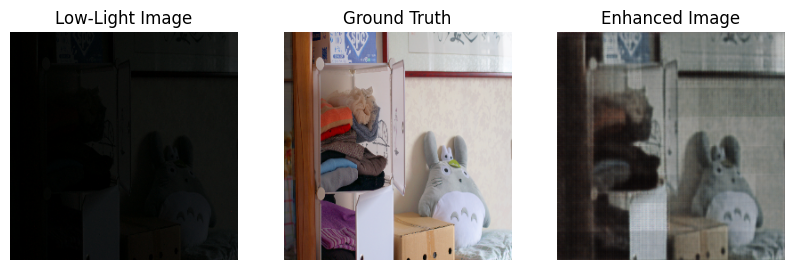

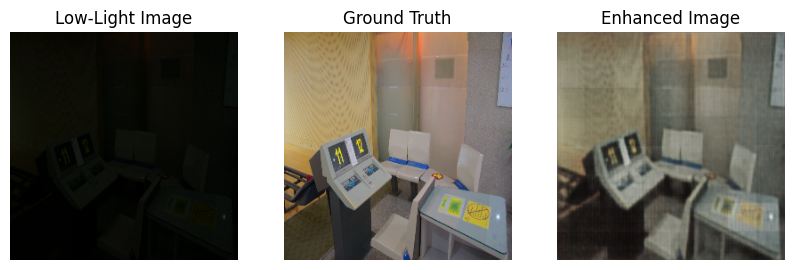

In [27]:
predict_images(test_low_images, test_high_images, count=5, size=SIZE)